# Algorítmo de Q-Learning

En este ejercicio vamos a probar el algorítmo de Q-learning como un representatnte de los métodos off-policy. Nuestro objetivo, es evaluar el algoritmo sobre distintos ambientes. Para cada uno de los ambientes deben ejecutar un agente de Q-learning en el ambiente, evaluar su ejecución y validar la efectividad del aprendizaje del agente entrenado sobre el ambiente.


El algoritmo de Q-learning está basado en la siguente funcionalidad (que puede estar integrado con el agente o ser implementado dentro de su propio modulo).

- El algoritmo debe tener acceso a todos los parámatros de aprendizaje (e.g., `alpha`, `gamma`, `epsilon`), el ambente, el agente y la memoria (la q-tabla).

Junto con las siguientes funciones:
- `run` que no recive ningún parámetro y se encarga de ejecutar el cíclo del agente (hasta llegar a convergencia) escogiendo la acción a ejecutar, ejecutando el paso y actualizando la función de aprendizaje
- `step` que recive una accióna ejecutar y la ejecuta efectivamente, retornando la recompensa, la informaciǿn si se llego al final del episodio y el estado de final luego de ejecutar la acción
- `get_reward` que recive la acción, el estado actual y el nuevo estado para calcular la recompensa que obtiene el agente de la ejecución de la acción.


## Task 1.  

Como primera tareas, utilice la implementación de Q-learning en el ambiente de cliff-walk (basado en el ambiente de Gridworld utilizdo anteriormente).
Recuerde que en este ambiente la recompensa por caer al barranco es de -100 y la recompensa de cada paso es -1.
Para la ejecución vamos a suponer acciones determinísticas.

![cliff-walk](img/cliff-walk.png)

Cuál es la diferencia entre las dos implementaciones (SARSA y Q-learning) del problema (que observaciones puede hacer)?

In [419]:
 # Enviroment and MDP definition

import random

class EnvironmentNuevo:
    def __init__(self, board, exit_state):
        self.board = board
        self.nrows = len(board)
        self.ncols = len(board[0]) 
        self.initial_state = self._find_initial_state()
        self.current_state = self.initial_state
        self.actions = ['up', 'right', 'down', 'left', 'exit']
        # self.P = self._build_transition_matrix()
        self.exit_state = exit_state
        
    def _build_transition_matrix(self):
        nA = len(self.actions)
    
        P = [[[[0 for _ in range(nA)] for _ in range(nA)]
              for _ in range(self.ncols)]
              for _ in range(self.nrows)]
    
        for i in range(self.nrows):
            for j in range(self.ncols):
            
                if self.board[i][j] == '#':
                    continue
                
                # Si es estado terminal
                if self._is_exit(i, j):
                    P[i][j][4][4] = 1.0  # exit → exit
                    continue
                
                for a in range(4):  # solo up,right,down,left
                
                    clockwise = (a + 1) % 4
                    counterclock = (a - 1) % 4
    
                    P[i][j][a][a] = 0.6
                    P[i][j][a][clockwise] = 0.2
                    P[i][j][a][counterclock] = 0.1
                    P[i][j][a][a] += 0.1  # 10% quedarse = misma acción
    
        return P

    def _find_initial_state(self):
        for i in range(self.nrows):
            for j in range(self.ncols):
                if self.board[i][j] == 'S':
                    return (i, j)
        return (1, 1)


    def _is_exit(self, r, c):
        return self.exit_state == (r, c) or self.board[r][c] == '-100'

    def _move(self, r, c, action):
        dr, dc = 0, 0
        if action == 'up':
            dr = -1
        elif action == 'down':
            dr = 1
        elif action == 'left':
            dc = -1
        elif action == 'right':
            dc = 1

        nr, nc = r + dr, c + dc
        if nr < 0 or nr >= self.nrows or nc < 0 or nc >= self.ncols:
            return r, c
        if self.board[nr][nc] == '#':
            return r, c
        return nr, nc
   
    def _get_reward(self, r, c):
        if self._is_exit(r, c):
            return float(self.board[r][c])
        if self.board[r][c] == '#':
            return 0
        if self.board[r][c] == 'S':
            return -1
        return float(self.board[r][c])
    
    def get_current_state(self):
        return self.current_state

    def get_posible_actions(self, state):
        r, c = state
        if self._is_exit(r, c):
            return ['exit']
        if self.board[r][c] == '#':
            return []
        return ['up', 'right', 'down', 'left']
   
    def do_action(self, idx_action):
        r, c = self.current_state
    
        # Si es terminal
        if self._is_exit(r, c):
            if idx_action == 4:
                return float(self.board[r][c]), self.current_state
            return 0, self.current_state
    
        # Elegir acción real 
        real_action = self.actions[idx_action]
    
        nr, nc = self._move(r, c, real_action)
        self.current_state = (nr, nc)
        
    
        reward = self._get_reward(nr, nc)
    
        return reward, self.current_state

    def reset(self):
        self.current_state = self.initial_state

    def is_terminal(self):
        r, c = self.current_state
        return self._is_exit(r, c)
    

env=EnvironmentNuevo([
    ['-1']*12,
    ['-1']*12,
    ['-1']*12,
    ['-1']*12,
    ['S'] + ['-100']*10 + ['100']
], exit_state=(4, 11))

In [420]:
import numpy as np

class QLearningAgent:
    def __init__(self, env, agent=None, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env     = env
        self.agent   = agent
        self.alpha   = alpha
        self.gamma   = gamma
        self.epsilon = epsilon

        self.q_table = {
            (r, c): [0.0] * len(env.actions)
            for r in range(env.nrows)
            for c in range(env.ncols)
        }

    # ── ciclo principal ──────────────────────────────────────────────
    def run(self, n_episodes=1000, theta=1e-4, patience=5):
        stable_count = 0

        for episode in range(n_episodes):
            # snapshot ANTES del episodio (copia profunda del dict)
            q_prev = {s: vals[:] for s, vals in self.q_table.items()}

            self.env.reset()
            state = self.env.get_current_state()

            while not self.env.is_terminal():
                action               = self._choose_action(state)
                reward, done, next_state = self.step(action)

                # actualizar Q-tabla
                best_next = max(self.q_table[next_state])
                td_target = reward + self.gamma * best_next * (not done)
                td_error  = td_target - self.q_table[state][action]
                self.q_table[state][action] += self.alpha * td_error

                state = next_state

            # ── chequeo de convergencia ──────────────────────────────
            delta = max(
                abs(self.q_table[s][a] - q_prev[s][a])
                for s in self.q_table
                for a in range(len(self.env.actions))
            )

            if delta < theta:
                stable_count += 1
                if stable_count >= patience:
                    print(f"Convergencia en episodio {episode + 1} (Δ={delta:.2e})")
                    break
            else:
                stable_count = 0

    # ── un paso en el entorno ────────────────────────────────────────
    def step(self, action):
        reward, next_state = self.env.do_action(action)
        done = self.env.is_terminal()
        return reward, done, next_state

    # ── recompensa de la transición ──────────────────────────────────
    def get_reward(self, action, state, next_state):
        r, c = next_state
        return self.env._get_reward(r, c)

    # ── política ε-greedy ────────────────────────────────────────────
    def _choose_action(self, state):
        possible = self.env.get_posible_actions(state)
        # mapear nombre de acción a índice
        indices = [self.env.actions.index(a) for a in possible]

        if np.random.rand() < self.epsilon:
            return np.random.choice(indices)            # explorar
        # explotar solo entre acciones válidas
        q_vals = [self.q_table[state][i] for i in indices]
        return indices[int(np.argmax(q_vals))]

In [421]:
QAgent = QLearningAgent(env, None)
QAgent.run()

Convergencia en episodio 574 (Δ=1.48e-09)


In [422]:
import numpy as np
import matplotlib.pyplot as plt

def plot_policy(Q, env,action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←', 4: 'E'}):
    

    path = get_optimal_path(Q, env)

    fig, ax = plt.subplots()

    for r in range(env.nrows):
        for c in range(env.ncols):

            best_action = int(np.argmax(Q[(r, c)]))
            if (r, c) == env.exit_state:
                best_action = 4

            symbol = action_symbols[best_action]

            if (r, c) in path:
                color, size = 'red', 18
            else:
                color, size = 'black', 14

            ax.text(c, env.nrows - r - 1, symbol,
                    ha='center', va='center',
                    fontsize=size, color=color)

    ax.set_xticks(range(env.ncols))
    ax.set_yticks(range(env.nrows))
    ax.grid(True)
    plt.show()


def get_optimal_path(Q, env, max_steps=100):
    goal  = env.exit_state
    state = env._find_initial_state()
    path  = [state]

    for _ in range(max_steps):
        if state == goal:
            break

        action = int(np.argmax(Q[(state)]))
        r, c   = state

        if action == 0:   r = max(r - 1, 0)
        elif action == 1: c = min(c + 1, env.ncols - 1)
        elif action == 2: r = min(r + 1, env.nrows - 1)
        elif action == 3: c = max(c - 1, 0)

        state = (r, c)
        path.append(state)

    return path

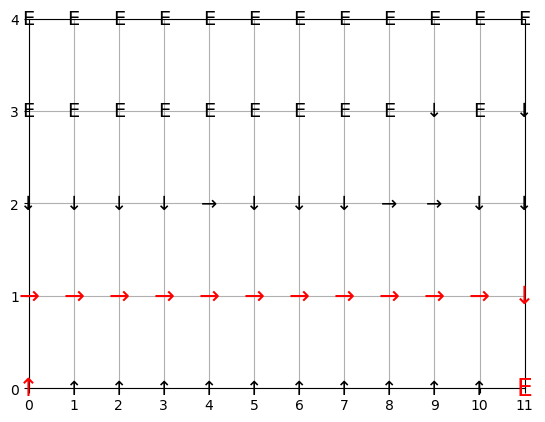

In [423]:
plot_policy(QAgent.q_table, QAgent.env)

Mi implementación de SARSA, con los mismos parámetros:

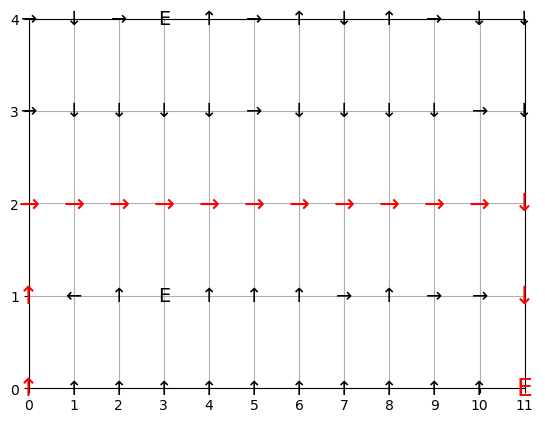

In [424]:
import numpy as np

class SARSA():
    def __init__(self, env, Q, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.env = env
        self.Q = Q
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    
    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            #exploration
            return np.random.randint(0, len(self.env.get_posible_actions(state)))
        else:
            #explotation
            return np.argmax(self.Q[state])
        
    def action_function(self, state1, action1, reward, state2, action2):
        #$Q(s,a) \leftarrow (1-\alpha)Q(s,a) + \alpha[R(s) + \gamma Q(s',a')] $
        self.Q[state1][action1] = (1 - self.alpha) * self.Q[state1][action1] + self.alpha * (reward + self.gamma * self.Q[state2][action2])
        
    
 
agent = SARSA(env, Q=np.zeros((env.nrows, env.ncols, len(env.actions))))

n_episodes = 10000

for _ in range(n_episodes):
    env.reset()
    state1 = env.get_current_state()
    action1=agent.choose_action(state1)
    # print(f"Episode {_+1}/{n_episodes}")
    while True:
        # if _ == n_episodes - 1:
            # print(f"State: {state1}, Action: {env.actions[action1]}")
            # print("epsilon: ", agent.epsilon)
        
        reward, state2 = env.do_action(action1)
        
        action2 = agent.choose_action(state2)
        agent.action_function(state1, action1, reward, state2, action2)
        
        state1 = env.get_current_state()
        action1 = action2
        if env.is_terminal():
            break
        
    agent.epsilon = agent.epsilon * 0.99  # Decay epsilon for episodes
plot_policy(agent.Q, env)


Las implementaciones de SARSA Y QLearning difieren en 
Más allá de la diferencia teórica, en el código concreto hay tres diferencias:
Estructura de la Q-tabla. SARSA usa un array numpy (nrows, ncols, n_acciones) indexado con Q[r, c, a], mientras que Q-learning usa un dict {(r,c): [lista]} indexado con Q[(r,c)][a] (esto para la generalización de los proximos casos).
Cuándo se escoge la siguiente acción. En SARSA action2 se elige antes de actualizar la tabla — es parte de la fórmula. En Q-learning nunca se elige explícitamente a'; se usa max(Q[s']) directamente.
Epsilon decay. SARSA lo aplica al final de cada episodio (epsilon *= 0.99), mientras que en Q-learning se lo deja fijo durante todo el entrenamiento, se tomó esta decisión.

## Task 2. 

Para esta tarea vamos a utilizar un ambiente más complejo donde el agente debe completar tareas intermedias para completar el objetivo del agente.

![Locked-door](img/locked-door.png)

El ambiente consiste en dos habitaciones separadas por una puerta con llave. El objetivo del agente, que aparece en el cuarto de la izquierda, es llegar a la casilla de salida en el cuarto de la derecha (desconosida para el agente).

Para poder alcanzar el objetivo, el agente debe abrir la puerta con una llave (del mismo color de la puerta, que por defecto siempre lo será (azul)) que se encuentra en alguna posición en el cuarto. Sin embargo para poder abrir la puerta, el agente debe primero retirar una bola que se encuentra bloqueandola.

Por lo tanto, para poder alcanzar el objetivo, el agente tiene, ademas de las acciones de movimiento, acciones para recoger un objeto (llave o bola) y para abrir la puerta.

Su misión es definir el problema (sistema de recompensas) para permitir al agente alcanzar el objetivo. Entrenar al agente en el ambiente y poder explotarlo. Además de esto su programa debe ser capaz de grabar la memoria del agente (i.e., la Q-tabla).

Asegurese de guardar la información de las distintas pruebas que realice sobre el agente, para dejarlas ver en un pequeño reporte presentado los resultados.

In [425]:
import random
import numpy as np


class RoomEnvironment:
    ACTIONS = ['up', 'down', 'left', 'right', 'pick', 'open_door']

    EMPTY = ''
    WALL  = '#'
    START = 'S'
    DOOR  = 'D'
    KEY   = 'K'
    BALL  = 'B'
    EXIT  = 'E'

    def __init__(self,
                 n_keys=1,
                 key_colors=None,
                 n_balls=1,
                 randomize_start=False,
                 randomize_keys=False):

        self.n_keys          = n_keys
        self.key_colors      = key_colors or ['blue'] * n_keys
        self.n_balls         = n_balls
        self.randomize_start = randomize_start
        self.randomize_keys  = randomize_keys

        self._base_board = [
            ['', '', '', '',  '#', '', 'E',  '', ''],
            ['', '', '', 'K', '#', '', '',   '', ''],
            ['S', '', '', '', '#', '', '',   '', ''],
            ['', '', '', 'B', 'D', '', '',   '', ''],
        ]

        self.nrows = len(self._base_board)
        self.ncols = len(self._base_board[0])

        self.initial_state = self._find_symbol('S')
        self.door_pos      = self._find_symbol('D')
        self.exit_pos      = self._find_symbol('E')
        self.exit_state     = self.exit_pos

        # Precalcular celdas libres del lado izquierdo (sin puerta ni salida)
        door_col = self.door_pos[1]
        self._left_cells_base = [
            (r, c) for r in range(self.nrows)
                   for c in range(door_col)
                   if self._base_board[r][c] not in ('#', 'D', '+100', 'E')
        ]

        self.reset()
    def _find_initial_state(self):
        return self.initial_state
        

    # ── búsqueda en board base ───────────────────────────────────────
    def _find_symbol(self, symbol):
        for r in range(self.nrows):
            for c in range(self.ncols):
                if self._base_board[r][c] == symbol:
                    return (r, c)
        return None

    def _find_all(self, symbol):
        return [(r, c) for r in range(self.nrows)
                        for c in range(self.ncols)
                        if self._base_board[r][c] == symbol]

    def _left_cells(self, exclude=set()):
        return [p for p in self._left_cells_base if p not in exclude]

    # ── construir board del episodio ─────────────────────────────────
    def _build_board(self):
        board = [row[:] for row in self._base_board]
        occupied = {self.door_pos, self.exit_pos}

        # Posición inicial
        if self.randomize_start:
            self.agent_pos = random.choice(self._left_cells(occupied))
        else:
            self.agent_pos = self.initial_state
        occupied.add(self.agent_pos)

        # Bolas
        ball_positions_base = self._find_all('B')
        self.ball_positions = {}
        for bp in ball_positions_base[:self.n_balls]:
            self.ball_positions[bp] = True
            occupied.add(bp)

        # Llaves
        if self.randomize_keys:
            free = self._left_cells(occupied)
            self.key_positions = {}
            for i in range(self.n_keys):
                pos = random.choice(free)
                self.key_positions[pos] = self.key_colors[i % len(self.key_colors)]
                free.remove(pos)
                occupied.add(pos)
        else:
            base_key = self._find_symbol('K')
            self.key_positions = {
                base_key: self.key_colors[i % len(self.key_colors)]
                for i in range(self.n_keys)
            }

        for (r, c), color in self.key_positions.items():
            board[r][c] = f'K_{color}'
        for (r, c) in self.ball_positions:
            board[r][c] = 'B'

        self.board = board

    # ── reset ────────────────────────────────────────────────────────
    def reset(self):
        self._build_board()
        self.inventory      = []
        self.balls_removed  = set()
        self.door_open      = False

        # FIX: contador O(1) para saber si todas las bolas están removidas
        self._balls_remaining = len(self.ball_positions)

        return self.get_current_state()

    # ── estado ───────────────────────────────────────────────────────
    def get_current_state(self):
        return (
            self.agent_pos,
            tuple(sorted(self.inventory)),
            frozenset(self.balls_removed),
            self.door_open,
        )

    def get_current_pos(self):
        return self.agent_pos

    # ── bola bloquea el camino a la puerta ──────────────────────────
    def _blocks_door(self, ball_pos):
        """
        Una bola bloquea si está en la misma fila que la puerta
        y entre el agente y la puerta (columna).
        """
        dr, dc = self.door_pos
        br, bc = ball_pos
        ar, ac = self.agent_pos
        if br != dr or self.door_open:
            return False
        # la bola debe estar entre el agente y la puerta en columna
        min_c = min(ac, dc)
        max_c = max(ac, dc)
        return min_c <= bc <= max_c

    # ── acciones válidas ─────────────────────────────────────────────
    def get_possible_actions(self, state=None):
        actions = ['up', 'down', 'left', 'right']
        r, c = self.agent_pos

        # pick llave: solo si es azul y no la tenemos
        if (r, c) in self.key_positions:
            # color = self.key_positions[(r, c)]
            # if color == 'blue' and 'blue' not in self.inventory:
                actions.append('pick')

        # pick bola: solo si está en esta celda, no removida, y bloquea la puerta
        if (r, c) in self.ball_positions and \
                (r, c) not in self.balls_removed:
            actions.append('pick')

        # open_door: estar en la puerta + tener llave azul (sin condición de bolas)
        if (r, c) == self.door_pos and self.door_open == False:
            actions.append('open_door')
            # print(f"Acción 'open_door' disponible en {(r, c)} con inventario {self.inventory} y bolas restantes {self._balls_remaining}")

        return actions

    def is_terminal(self):
        return self.agent_pos == self.exit_pos

    # ── ejecutar acción ──────────────────────────────────────────────
    def do_action(self, action_idx):
        action = self.ACTIONS[action_idx]
        r, c   = self.agent_pos
    
        # penalización base por paso (fuerza caminos cortos)
        reward = -2
    
        if action in ('up', 'down', 'left', 'right'):
            nr, nc = self._move(r, c, action)
            self.agent_pos = (nr, nc)
    
            self.board[nr][nc] = 'A'
            if (nr, nc) != self.door_pos:
                self.board[r][c] = self._restore_cell(r, c)
    
        elif action == 'pick':
        
            # ─── LLAVE ─────────────────────────────
            if (r, c) in self.key_positions:
                color = self.key_positions[(r, c)]
    
                if color == 'blue' and 'blue' not in self.inventory:
                    self.inventory.append('blue')
                    reward = 150   # ↑ subir recompensa → prioridad alta
                else:
                    reward = -30   # castigar recoger inútil
    
            # ─── BOLA ─────────────────────────────
            elif (r, c) in self.ball_positions and \
                 (r, c) not in self.balls_removed:
    
                if 'blue' in self.inventory:
                    self.balls_removed.add((r, c))
                    self._balls_remaining -= 1
                    self.board[r][c] = ''
    
                    # recompensa progresiva (incentiva limpiar todas)
                    reward = 120
                else:
                    reward = -40   # intentar sin llave
    
            else:
                reward = -60       # pick completamente inválido
    
        elif action == 'open_door':
        
            if (r, c) == self.door_pos and 'blue' in self.inventory:
            
                # opcional: exigir limpiar bolas antes
                if self._balls_remaining == 0:
                    self.door_open = True
                    self.board[self.door_pos[0]][self.door_pos[1]] = ''
                    reward = 400   # sub-goal MUY importante
                else:
                    reward = -80   # abrir antes de tiempo
            else:
                reward = -120      # intento inválido fuerte
    
        # ─── TERMINAL ─────────────────────────────
        if self.is_terminal():
            reward = 1200   # debe dominar TODO
    
        return reward, self.get_current_state()
    
    # ── restaurar celda al salir ─────────────────────────────────────
    def _restore_cell(self, r, c):
        if (r, c) in self.key_positions and \
                self.key_positions[(r, c)] not in self.inventory:
            return f'K_{self.key_positions[(r, c)]}'
        if (r, c) in self.ball_positions and \
                (r, c) not in self.balls_removed:
            return 'B'
        base = self._base_board[r][c]
        return '' if base == 'S' else base

    # ── movimiento ───────────────────────────────────────────────────
    def _move(self, r, c, action):
        dr, dc = {'up': (-1, 0), 'down': (1, 0),
                  'left': (0, -1), 'right': (0, 1)}[action]
        nr, nc = r + dr, c + dc
        

        if nr < 0 or nr >= self.nrows or nc < 0 or nc >= self.ncols:
            return r, c
        if self.board[nr][nc] == '#':
            return r, c
        # if (nr, nc) == self.door_pos:
            # print(f"Intento de mover a la puerta en {(nr, nc)} con inventario {self.inventory} y bolas restantes {self._balls_remaining}")
        return nr, nc

    # ── visualización ────────────────────────────────────────────────
    def render(self):
        symbols = {
            '':       '·',
            '#':      '█',
            'S':      'S',
            'D':      'D',
            '+100':   'X',
            'A':      '@',
            'B':      'B',
            'K_blue': 'Kb',
            'K_red':  'Kr',
            'E':      'E',
        }
        for row in self.board:
            print(' '.join(symbols.get(cell, cell).rjust(2) for cell in row))
        print(f"  inventario: {self.inventory} | "
              f"bolas removidas: {len(self.balls_removed)} | "
              f"puerta: {'abierta' if self.door_open else 'cerrada'} |"
              f"posición: {self.agent_pos} |"
              f"acciones posibles: {self.get_possible_actions()}")

In [426]:
env2=RoomEnvironment()


In [427]:
import numpy as np
from collections import defaultdict


class QLearningAgent:
    def __init__(self,
                 env,
                 alpha=0.1,
                 gamma=0.9,
                 epsilon_start=0.25):
        self.env   = env
        self.alpha = alpha
        self.gamma = gamma

        # Epsilon con decaimiento exponencial: explora al inicio, explota al final
        self.epsilon       = epsilon_start


        self._action_index = {a: i for i, a in enumerate(env.ACTIONS)}
        self._n_actions    = len(env.ACTIONS)

        # float32: mitad de memoria, mismo rendimiento para Q-Learning
        self.q_table = defaultdict(
            lambda: np.zeros(self._n_actions, dtype=np.float32)
        )

    # ── ciclo principal ──────────────────────────────────────────────
    def run(self, n_episodes=2000, theta=1e-4, patience=5,
            max_steps=1000, log_every=100):

        # Cachear referencias locales — evita lookup de atributo en cada step
        env         = self.env
        q_table     = self.q_table
        alpha       = self.alpha
        gamma       = self.gamma
        action_idx  = self._action_index


        stable_count = 0

        for episode in range(1, n_episodes + 1):
            state             = env.reset()
            episode_max_delta = 0.0
            done              = False
            steps             = 0

            while not done and steps < max_steps:
                steps += 1

                # ── elegir acción ─────────────────────────────────────
                indices = [action_idx[a]
                           for a in env.get_possible_actions()]

                if np.random.random() < self.epsilon:
                    action = indices[int(np.random.random() * len(indices))]
                else:
                    q_vals = q_table[state]
                    action = max(indices, key=lambda i: q_vals[i])

                # ── step en el env ────────────────────────────────────
                reward, next_state = env.do_action(action)
                done = env.is_terminal()   # una sola llamada por step

                # ── actualización Q ───────────────────────────────────
                if done:
                    # print(f"Terminal reached in {steps} steps with reward {reward}")
                    best_next = 0.0
                else:
                    best_next = float(q_table[next_state].max())

                td_error = (reward + gamma * best_next) - q_table[state][action]
                update   = alpha * td_error
                q_table[state][action] += update

                abs_update = update if update > 0 else -update
                if abs_update > episode_max_delta:
                    episode_max_delta = abs_update

                state = next_state
            if episode % 100 == 0:
                self.epsilon *= 0.99  # Decaimiento exponencial de epsilon


            # ── log ───────────────────────────────────────────────────
            if episode % log_every == 0:
                print(f"ep {episode:>6}/{n_episodes} | "
                      f"steps: {steps:>4} | "
                      f"estados: {len(q_table):>5} | "
                      f"ε={self.epsilon:.3f} | "
                      f"Δ={episode_max_delta:.2e}")

            # ── convergencia ──────────────────────────────────────────
            if episode_max_delta < theta:
                stable_count += 1
                if stable_count >= patience:
                    print(f"Convergencia en episodio {episode} "
                          f"(Δ={episode_max_delta:.2e}, ε={self.epsilon:.3f})")
                    break
            else:
                stable_count = 0

    # ── política greedy para evaluación ─────────────────────────────
    def best_action(self, state):
        indices = [self._action_index[a]
                   for a in self.env.get_possible_actions()]
        q_vals  = self.q_table[state]
        return max(indices, key=lambda i: q_vals[i])

    # ── ejecutar un episodio greedy y retornar trayectoria ───────────
    def evaluate(self, max_steps=200, render=False):
        env   = self.env
        state = env.reset()
        total_reward = 0
        trajectory   = [env.get_current_pos()]

        for _ in range(max_steps):
            if render:
                env.render()
            action        = self.best_action(state)
            reward, state = env.do_action(action)
            total_reward += reward
            trajectory.append(env.get_current_pos())
            if env.is_terminal():
                break

        if render:
            env.render()

        return total_reward, trajectory

In [428]:
QAgent2 = QLearningAgent(env2)
print(len(QAgent2.q_table))
QAgent2.run()

0
ep    100/2000 | steps:   23 | estados:    95 | ε=0.247 | Δ=6.94e+01
ep    200/2000 | steps:   26 | estados:   106 | ε=0.245 | Δ=3.71e+01
ep    300/2000 | steps:   27 | estados:   106 | ε=0.243 | Δ=4.39e+01
ep    400/2000 | steps:   21 | estados:   106 | ε=0.240 | Δ=1.28e+01
ep    500/2000 | steps:   17 | estados:   106 | ε=0.238 | Δ=1.19e+01
ep    600/2000 | steps:   24 | estados:   106 | ε=0.235 | Δ=5.95e+01
ep    700/2000 | steps:   17 | estados:   106 | ε=0.233 | Δ=6.95e+00
ep    800/2000 | steps:   22 | estados:   106 | ε=0.231 | Δ=6.27e+00
ep    900/2000 | steps:   20 | estados:   106 | ε=0.228 | Δ=1.68e+00
ep   1000/2000 | steps:   17 | estados:   106 | ε=0.226 | Δ=1.14e-01
ep   1100/2000 | steps:   20 | estados:   106 | ε=0.224 | Δ=7.76e-02
ep   1200/2000 | steps:   18 | estados:   106 | ε=0.222 | Δ=2.91e-02
ep   1300/2000 | steps:   18 | estados:   106 | ε=0.219 | Δ=2.08e-02
ep   1400/2000 | steps:   18 | estados:   106 | ε=0.217 | Δ=2.27e-01
ep   1500/2000 | steps:   15 | e

In [429]:
def run_policy(agent, env, max_steps=100):
    state = env.reset()

    env.render()
    print()

    for step in range(max_steps):

        if state not in agent.q_table:
            print("Estado no visto")
            break

        action_idx = np.argmax(agent.q_table[state])
        action = env.ACTIONS[action_idx]

        print(f"Step {step}: acción = {action}")

        reward, state = env.do_action(action_idx)

        env.render()
        print(f"reward = {reward}\n")

        if env.is_terminal():
            print("✅ TERMINÓ")
            break
run_policy(QAgent2, env2, max_steps=50)

 ·  ·  ·  ·  █  ·  E  ·  ·
 ·  ·  · Kb  █  ·  ·  ·  ·
 S  ·  ·  ·  █  ·  ·  ·  ·
 ·  ·  ·  B  D  ·  ·  ·  ·
  inventario: [] | bolas removidas: 0 | puerta: cerrada |posición: (2, 0) |acciones posibles: ['up', 'down', 'left', 'right']

Step 0: acción = up
 ·  ·  ·  ·  █  ·  E  ·  ·
 @  ·  · Kb  █  ·  ·  ·  ·
 ·  ·  ·  ·  █  ·  ·  ·  ·
 ·  ·  ·  B  D  ·  ·  ·  ·
  inventario: [] | bolas removidas: 0 | puerta: cerrada |posición: (1, 0) |acciones posibles: ['up', 'down', 'left', 'right']
reward = -2

Step 1: acción = right
 ·  ·  ·  ·  █  ·  E  ·  ·
 ·  @  · Kb  █  ·  ·  ·  ·
 ·  ·  ·  ·  █  ·  ·  ·  ·
 ·  ·  ·  B  D  ·  ·  ·  ·
  inventario: [] | bolas removidas: 0 | puerta: cerrada |posición: (1, 1) |acciones posibles: ['up', 'down', 'left', 'right']
reward = -2

Step 2: acción = right
 ·  ·  ·  ·  █  ·  E  ·  ·
 ·  ·  @ Kb  █  ·  ·  ·  ·
 ·  ·  ·  ·  █  ·  ·  ·  ·
 ·  ·  ·  B  D  ·  ·  ·  ·
  inventario: [] | bolas removidas: 0 | puerta: cerrada |posición: (1, 2) |acciones posibles: ['u

In [430]:
import matplotlib.pyplot as plt
import numpy as np

def plot_policy_rollout(agent, env, max_steps=100, filename=None):
    state = env.reset()

    path = []
    actions_taken = []

    path.append(env.get_current_pos())

    for step in range(max_steps):

        if state not in agent.q_table:
            print("Estado no visto")
            break

        action_idx = np.argmax(agent.q_table[state])
        action = env.ACTIONS[action_idx]

        reward, state = env.do_action(action_idx)

        path.append(env.get_current_pos())
        actions_taken.append(action)

        if env.is_terminal():
            print("✅ TERMINÓ")
            break

    # ─── PLOT ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(env.ncols, env.nrows))

    # dibujar grid base
    for r in range(env.nrows):
        for c in range(env.ncols):
            cell = env._base_board[r][c]

            color = '#1e1e1e'
            if cell == '#': color = '#2c2c2c'
            elif cell == 'D': color = '#1a3a5c'
            elif cell == 'E': color = '#1a5c2a'
            elif cell == 'B': color = '#5c1a1a'
            elif cell == 'S': color = '#3a3a1a'

            ax.add_patch(plt.Rectangle(
                (c, env.nrows - r - 1), 1, 1,
                color=color, ec='#444'
            ))

    # ─── dibujar trayectoria ─────────────────────
    for i in range(len(path)-1):
        (r1, c1) = path[i]
        (r2, c2) = path[i+1]

        x1, y1 = c1 + 0.5, env.nrows - r1 - 0.5
        x2, y2 = c2 + 0.5, env.nrows - r2 - 0.5

        ax.arrow(x1, y1,
                 x2 - x1, y2 - y1,
                 head_width=0.15, length_includes_head=True)

        # acción como texto
        action = actions_taken[i]
        ax.text(x1, y1, action[0].upper(),
                ha='center', va='center',
                fontsize=8, color='white')

    # marcar inicio y fin
    start = path[0]
    end   = path[-1]

    ax.text(start[1]+0.5, env.nrows-start[0]-0.5,
            'S', ha='center', va='center', fontsize=12, color='yellow')

    ax.text(end[1]+0.5, env.nrows-end[0]-0.5,
            'E', ha='center', va='center', fontsize=12, color='green')

    ax.set_xlim(0, env.ncols)
    ax.set_ylim(0, env.nrows)
    ax.set_xticks(range(env.ncols))
    ax.set_yticks(range(env.nrows))
    ax.set_yticklabels(range(env.nrows-1, -1, -1))

    ax.set_title("Trayectoria siguiendo la política aprendida")
    ax.grid(False)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


✅ TERMINÓ


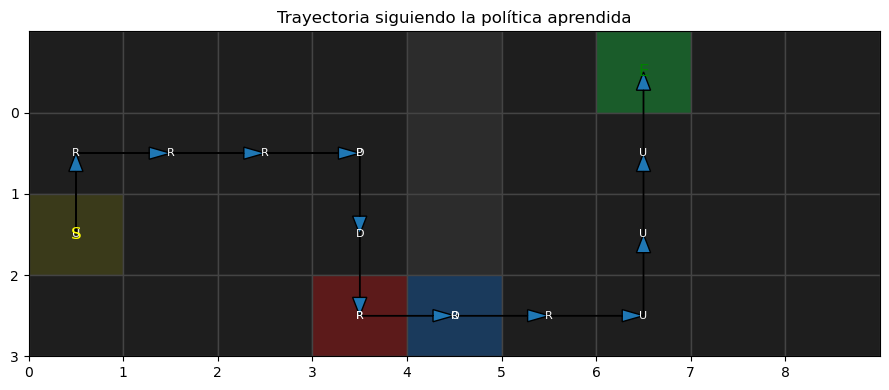

In [431]:
plot_policy_rollout(QAgent2, QAgent2.env)

In [432]:
import pickle
import json
import numpy as np

# ── guardar ─────────────────────────────────────────────────────────

def save_q_table(agent, path='q_table.pkl'):
    with open(path, 'wb') as f:
        pickle.dump(dict(agent.q_table), f)
    print(f"Q-tabla guardada en {path} ({len(agent.q_table)} estados)")


# ── cargar ───────────────────────────────────────────────────────────

def load_q_table(agent, path='q_table.pkl'):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    agent.q_table.update(data)
    print(f"Q-tabla cargada: {len(agent.q_table)} estados")

✅ TERMINÓ


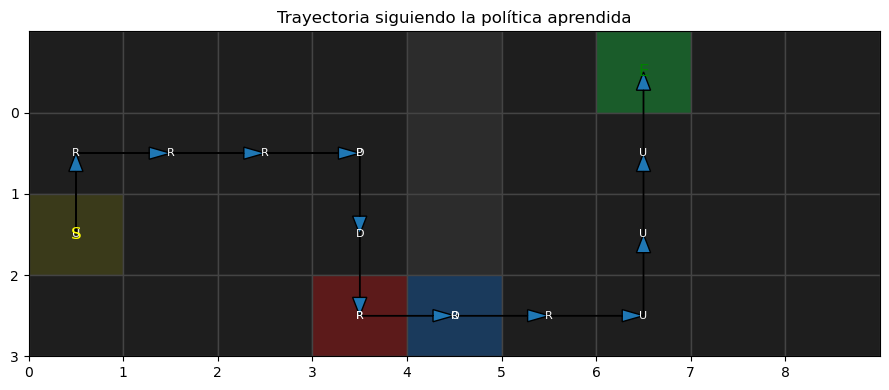

In [433]:
plot_policy_rollout(QAgent2, QAgent2.env, filename='policy_rollout.png')


In [434]:
import matplotlib.pyplot as plt
import numpy as np

def plot_q_values(agent, env,
                  fixed_inventory=(),
                  fixed_balls=frozenset(),
                  fixed_door=False,
                  title_suffix="",
                  filename=None):
    """
    Muestra un heatmap de V(s) = max_a Q(s,a) para cada celda.

    Parámetros:
    - fixed_inventory: tupla de llaves (ej: ('blue',))
    - fixed_balls: bolas removidas
    - fixed_door: estado de la puerta
    """

    grid = np.full((env.nrows, env.ncols), np.nan)

    # ─── construir grid de valores ─────────────────────
    for r in range(env.nrows):
        for c in range(env.ncols):

            # ignorar paredes
            if env._base_board[r][c] == '#':
                continue

            state = (
                (r, c),
                tuple(sorted(fixed_inventory)),
                frozenset(fixed_balls),
                fixed_door
            )

            if state in agent.q_table:
                grid[r, c] = np.max(agent.q_table[state])

    # ─── plot ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(env.ncols, env.nrows))

    # manejar caso todo nan
    vmin = np.nanmin(grid) if not np.all(np.isnan(grid)) else 0
    vmax = np.nanmax(grid) if not np.all(np.isnan(grid)) else 1

    im = ax.imshow(grid, cmap='RdYlGn', vmin=vmin, vmax=vmax)

    # ─── anotar valores ────────────────────────────────
    for r in range(env.nrows):
        for c in range(env.ncols):
            if not np.isnan(grid[r, c]):
                ax.text(c, r,
                        f'{grid[r,c]:.0f}',
                        ha='center', va='center',
                        fontsize=8, color='black')

    # ─── overlay de estructura del mapa ────────────────
    for r in range(env.nrows):
        for c in range(env.ncols):
            cell = env._base_board[r][c]

            if cell == '#':
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                                           color='black'))

            elif cell == 'D':
                ax.text(c, r, 'D', ha='center', va='center', color='blue')

            elif cell == 'E':
                ax.text(c, r, 'E', ha='center', va='center', color='green')

            elif cell == 'S':
                ax.text(c, r, 'S', ha='center', va='center', color='yellow')

    # ─── formato ──────────────────────────────────────
    ax.set_title(
        f"Q-values (max) | inv={list(fixed_inventory) or 'none'} "
        f"| door={'open' if fixed_door else 'closed'} {title_suffix}"
    )

    ax.set_xticks(range(env.ncols))
    ax.set_yticks(range(env.nrows))

    # invertir eje Y para que coincida con el render
    ax.set_yticklabels(range(env.nrows-1, -1, -1))

    plt.colorbar(im, ax=ax, label='max Q(s,a)')

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()


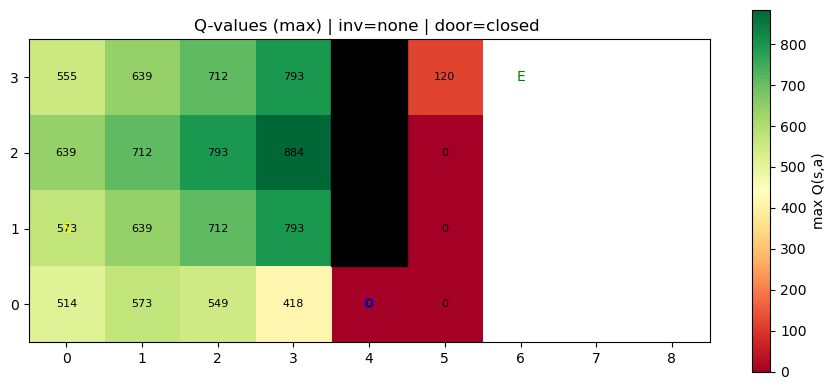

In [435]:
plot_q_values(QAgent2, QAgent2.env, filename='q_values.png')


## Task 3.

Como una tercera tarea adicional, vamos a probar (probablemente sin exito) la adaptabilidad del agente generado (i.e., el agente entrenado en el punto anterior).

Para esto pruebe los siguientes escenarios:
1. Aleatorize el punto de inicio del agente
1. Introduzca llaves de distintos colores en el ambiente, que se generar en posiciones aleatorias.

Entregue una solución para cada uno de los escenarios.


ep    100/5000 | steps:   17 | estados:    98 | ε=0.247 | Δ=4.24e+01
ep    200/5000 | steps:   16 | estados:    98 | ε=0.245 | Δ=3.05e+01
ep    300/5000 | steps:   14 | estados:    98 | ε=0.243 | Δ=2.11e+01
ep    400/5000 | steps:   21 | estados:    98 | ε=0.240 | Δ=4.96e+01
ep    500/5000 | steps:   15 | estados:    98 | ε=0.238 | Δ=3.52e+00
ep    600/5000 | steps:   14 | estados:    98 | ε=0.235 | Δ=3.25e+00
ep    700/5000 | steps:   14 | estados:    98 | ε=0.233 | Δ=2.89e+00
ep    800/5000 | steps:   25 | estados:   100 | ε=0.231 | Δ=3.36e+00
ep    900/5000 | steps:   14 | estados:   100 | ε=0.228 | Δ=3.44e+01
ep   1000/5000 | steps:   13 | estados:   100 | ε=0.226 | Δ=6.21e-02
ep   1100/5000 | steps:   17 | estados:   100 | ε=0.224 | Δ=1.98e-01
ep   1200/5000 | steps:   19 | estados:   100 | ε=0.222 | Δ=5.38e+01
ep   1300/5000 | steps:   14 | estados:   100 | ε=0.219 | Δ=1.83e-02
ep   1400/5000 | steps:   20 | estados:   100 | ε=0.217 | Δ=3.55e-01
ep   1500/5000 | steps:   20 | est

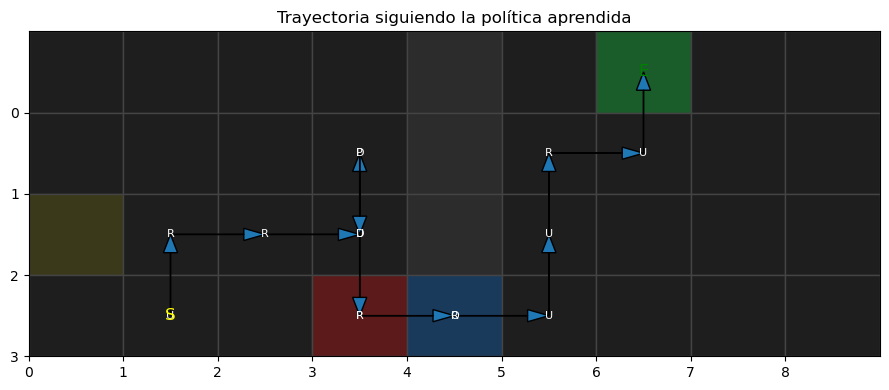

In [436]:
env3=RoomEnvironment(randomize_start=True)
QAgent3 = QLearningAgent(env3)
QAgent3.run(n_episodes=5000)
plot_policy_rollout(QAgent3, env3, filename='policy_random_start.png')


ep    100/5000 | steps:   71 | estados:   110 | ε=0.247 | Δ=4.69e+01
ep    200/5000 | steps: 1000 | estados:   110 | ε=0.245 | Δ=5.39e+00
ep    300/5000 | steps: 1000 | estados:   110 | ε=0.243 | Δ=1.23e+01
ep    400/5000 | steps:   18 | estados:   110 | ε=0.240 | Δ=4.96e+01
ep    500/5000 | steps: 1000 | estados:   110 | ε=0.238 | Δ=1.56e+01
ep    600/5000 | steps: 1000 | estados:   110 | ε=0.235 | Δ=1.68e+01
ep    700/5000 | steps:  136 | estados:   110 | ε=0.233 | Δ=3.52e+01
ep    800/5000 | steps: 1000 | estados:   110 | ε=0.231 | Δ=9.88e+00
ep    900/5000 | steps:  264 | estados:   110 | ε=0.228 | Δ=4.48e+01
ep   1000/5000 | steps: 1000 | estados:   110 | ε=0.226 | Δ=3.70e+00
ep   1100/5000 | steps: 1000 | estados:   110 | ε=0.224 | Δ=5.76e+00
ep   1200/5000 | steps: 1000 | estados:   110 | ε=0.222 | Δ=5.49e+00
ep   1300/5000 | steps: 1000 | estados:   110 | ε=0.219 | Δ=8.01e+00
ep   1400/5000 | steps:   15 | estados:   110 | ε=0.217 | Δ=5.26e+01
ep   1500/5000 | steps: 1000 | est

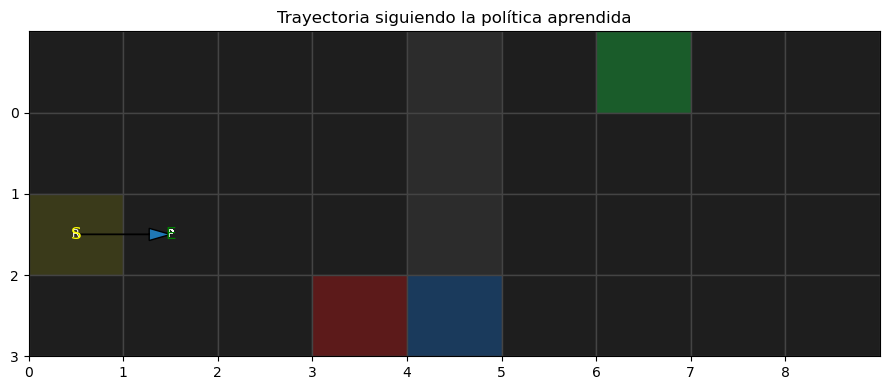

In [437]:
env3=RoomEnvironment(n_keys=2, key_colors=['blue', 'red'], n_balls=2,
                      randomize_keys=True)
QAgent3 = QLearningAgent(env3)
QAgent3.run(n_episodes=5000)
plot_policy_rollout(QAgent3, env3, filename='policy_multi_keys.png')
